## Plotting flower and fruit data

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
import pandas as pd

Read the data file and set indexing to datetime. I am using the modified CLEAN_forJenny_IntensiveSurvey2025 dataset for now, where I removed all rows that had NA on the fruit count. 

In [2]:
df = pd.read_csv('../data/processed/CLEAN_forJenny_IntensiveSurvey2025.csv') # Read the CSV file into a DataFrame
df['end'] = pd.to_datetime(df['end']) # Convert date column to datetime object
df.set_index('end', inplace=True) # Set the date column as the index of the DataFrame

Q1: **How does the flowering count and fruit yield change along the season?**

I do an intital analysis where I collapses all individual plants into a single daily total,
where all flower counts are summed together and all fruit counts are summed together for each day the survey is performed and plotted against time.

This is a good first step to see the overall seasonal trend of flower and fruits counts (combined) and observer outliers.

This was removed: *The drop in total flower count taking place on the 5th to 6th of June is due to a gap in the data where almost all plants are counted as (NA). I might remove this section of the datafile after consulting Hilde.* 

The dip in fruit count observed on the 4th of July could potentially be explained by a rotation in the volouteers performing the intensive servey. 

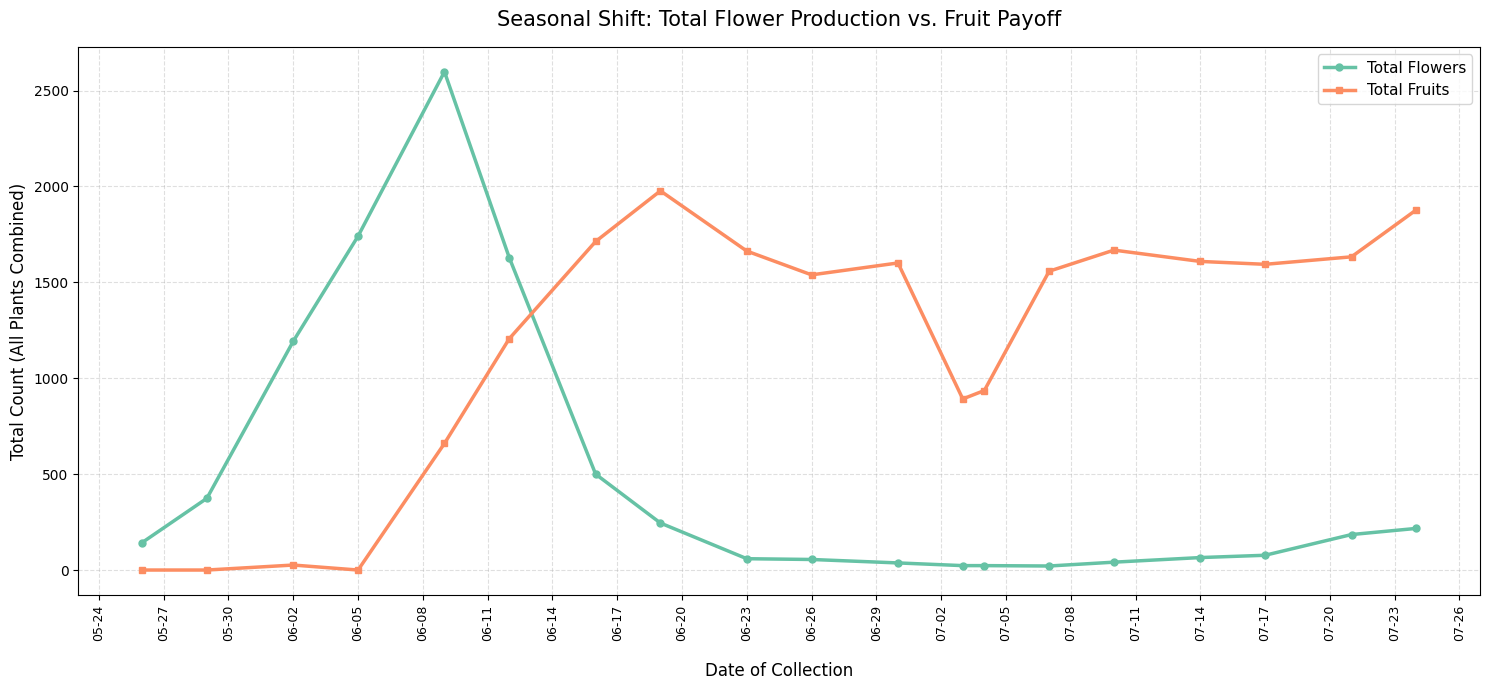

In [3]:
# Group by date index and calculate the sum for each day
daily_totals = df.groupby(df.index)[['Estim.Flowers.Nr', 'Estim.Fruits.Nr']].sum()

# Set up a slightly wider plot to accommodate all the date text
fig, ax = plt.subplots(figsize=(15, 7))

# Plot Total Flowers
ax.plot(
    daily_totals.index, 
    daily_totals['Estim.Flowers.Nr'], 
    color='#66c2a5', 
    linewidth=2.5, 
    marker='o', 
    markersize=5, 
    label='Total Flowers'
)

# Plot Total Fruits
ax.plot(
    daily_totals.index, 
    daily_totals['Estim.Fruits.Nr'], 
    color='#fc8d62', 
    linewidth=2.5, 
    marker='s', 
    markersize=5, 
    label='Total Fruits'
)

# Tell the X-axis to place a tick mark on every third day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

# Format how the date looks (e.g., '2026-06-01' or use '%b %d' for 'Jun 01')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# Rotate the text 90 degrees so they line up side-by-side like a barcode
plt.xticks(rotation=90, fontsize=9) 

# 3. Customize labels and design
plt.title('Seasonal Shift: Total Flower Production vs. Fruit Payoff', fontsize=15, pad=15)
plt.xlabel('Date of Collection', fontsize=12, labelpad=15)
plt.ylabel('Total Count (All Plants Combined)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=11, loc='upper right')

# Use tight_layout but explicitly leave space at the bottom for the vertical dates
plt.tight_layout()
plt.savefig('../results/total_seasonal_payoff_all_dates.png', dpi=300)
plt.show()

Q2: **How does flowering late in season effect the fruit yield?**

I start by plotting the data as box plots to see how the flower count vs fruit counts change over the season for different months. 

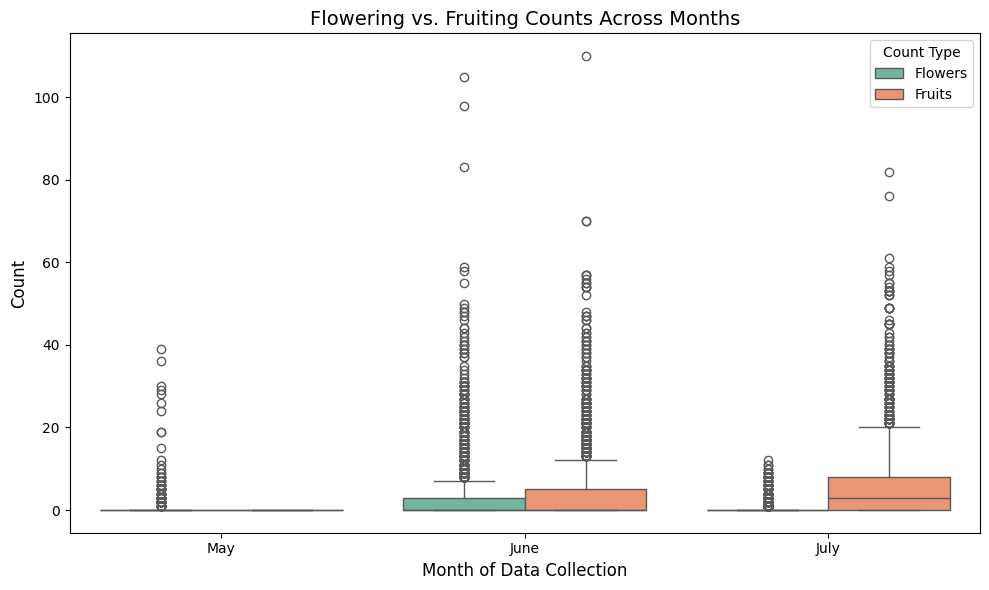

In [4]:
df['Month'] = df.index.month_name() # This will group the data into the 3 respective months of collection
# Reshape the data from wide format to long format
df_melted = df.melt(
    id_vars=['Month', 'PlantID'], 
    value_vars=['Estim.Flowers.Nr', 'Estim.Fruits.Nr'], 
    var_name='Count Type', 
    value_name='Count'
)

df_melted['Count Type'] = df_melted['Count Type'].map({
    'Estim.Flowers.Nr': 'Flowers',
    'Estim.Fruits.Nr': 'Fruits'
})
month_order = ['May', 'June', 'July'] 
df_melted['Month'] = pd.Categorical(df_melted['Month'], categories=month_order, ordered=True)

# Plot the overall seasonal trend of flower-to-fruit payoff (combined)
plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_melted, 
    x='Month', 
    y='Count', 
    hue='Count Type', 
    palette='Set2'
)

plt.legend(
    title='Count Type', 
    loc='upper right' # Keeps the clean 'Flowers' and 'Fruits' labels with perfect colors!
)

plt.title('Flowering vs. Fruiting Counts Across Months', fontsize=14)
plt.xlabel('Month of Data Collection', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('../results/flower_fruit_boxplot_aggregate.png', dpi=300)
plt.show()



Next, I isolate the subset of plants exhibiting late-season flowering (flowers observed in July) and plot them against the max yield of fruits. We comapre this to the plant IDs where no flowers where observed in July. 

/var/folders/7b/tyzwtcv13pz7k6db8rvxss_r0000gn/T/ipykernel_2658/2488208659.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


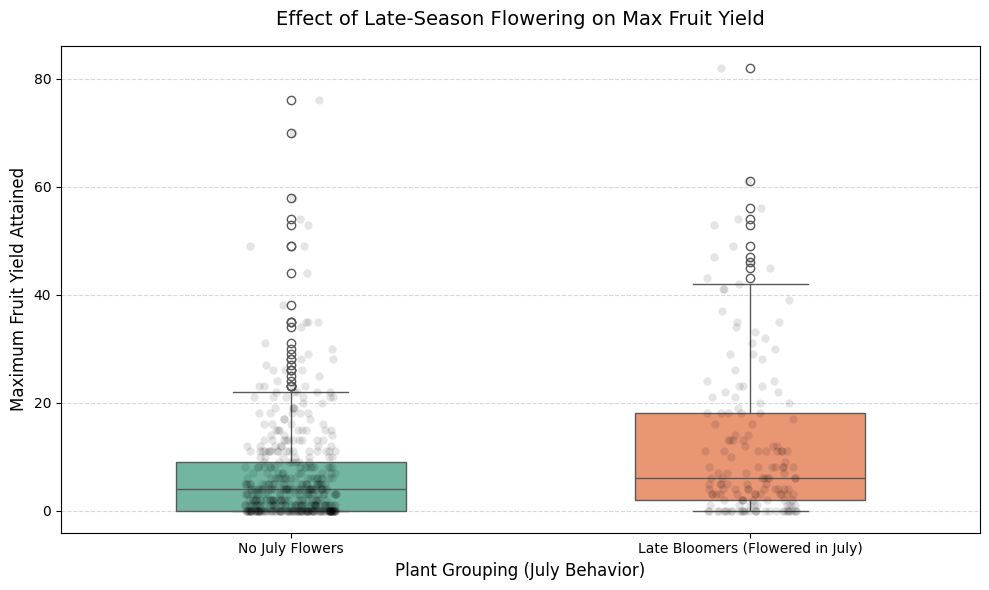

                                  count       mean        std  min  25%  50%  \
Group                                                                          
Late Bloomers (Flowered in July)  159.0  12.358491  15.213786  0.0  2.0  6.0   
No July Flowers                   441.0   6.918367  10.121878  0.0  0.0  4.0   

                                   75%   max  
Group                                         
Late Bloomers (Flowered in July)  18.0  82.0  
No July Flowers                    9.0  76.0  


In [5]:
# Isolate July data to identify the plant groups
july_data = df[df.index.month == 7]

# Calculate total July flowers per plant
july_flowers = july_data.groupby('Plant.ID')['Estim.Flowers.Nr'].sum()

# Group A: Plants that flowered in July (Total > 0)
late_bloomers_ids = july_flowers[july_flowers > 0].index.tolist()

# Group B: Plants with zero flowers in July
no_july_flowers_ids = july_flowers[july_flowers == 0].index.tolist()

# This will find the max fruit count in all months, it could have taken place before the second flowering period in July.
max_fruit_per_plant = df.groupby('Plant.ID')['Estim.Fruits.Nr'].max().reset_index()

# Assign each plant to its respective group
def assign_group(plant_id):
    if plant_id in late_bloomers_ids:
        return 'Late Bloomers (Flowered in July)'
    elif plant_id in no_july_flowers_ids:
        return 'No July Flowers'
    return 'Other'

max_fruit_per_plant['Group'] = max_fruit_per_plant['Plant.ID'].apply(assign_group)

# Filter out any 'Other' plants if they don't fit the criteria
comparison_df = max_fruit_per_plant[max_fruit_per_plant['Group'] != 'Other']

# Plot the comparison
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=comparison_df, 
    x='Group', 
    y='Estim.Fruits.Nr', 
    palette=['#66c2a5', '#fc8d62'],
    width=0.5
)

# Add individual plant dots over the boxplot so you can see every single plant ID's position
sns.stripplot(
    data=comparison_df, 
    x='Group', 
    y='Estim.Fruits.Nr', 
    color='black', 
    alpha=0.1, 
    size=6, 
    jitter=0.1
)

plt.title('Effect of Late-Season Flowering on Max Fruit Yield', fontsize=14, pad=15)
plt.xlabel('Plant Grouping (July Behavior)', fontsize=12)
plt.ylabel('Maximum Fruit Yield Attained', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../results/effect_on_late_season_flowering.png', dpi=300)

plt.show()

# Print out quick summary statistics
print(comparison_df.groupby('Group')['Estim.Fruits.Nr'].describe())

Q3: **Does plants with high flower count on average have a higher yield of fruits?**

To visualize the efficiency of flower to fruit ratio, I extract the max count of number of fruits and the total number of flowers counted for each plant ID. I then score each plant as the percentage of max number of fruits divided by total number of flowers. 
$$\text{Efficiency Score} = \left( \frac{\text{Max Fruits}}{\text{Total Flowers}} \right) \times 100$$
This score is then what I use to range each plant.

NameError: name 'mtick' is not defined

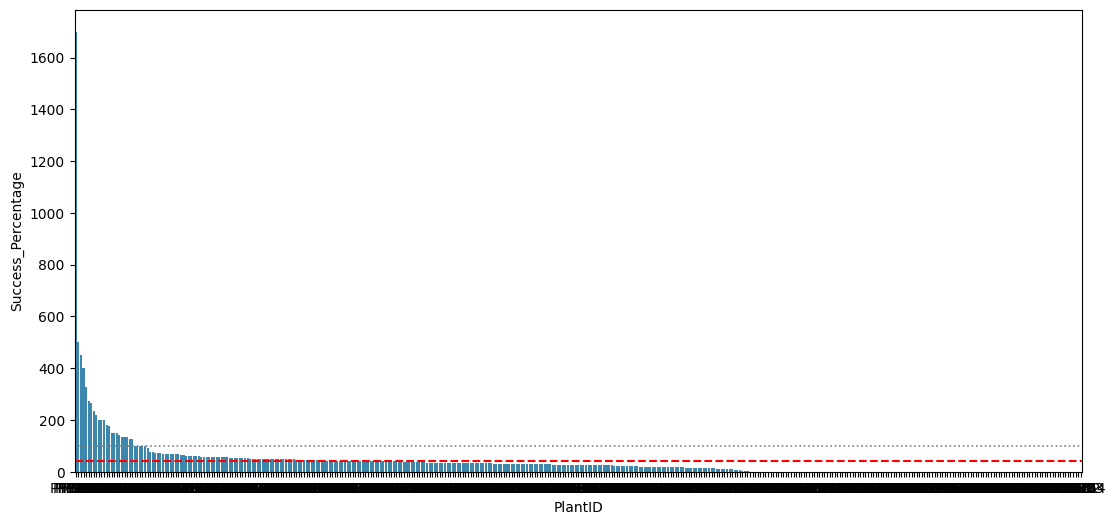

In [6]:
# Extract the total flowers count for each plant
flower_total = df.groupby('PlantID')[['Estim.Flowers.Nr']].sum()

# Extract the maximmum count of fruits seen for each plant, instead of the sum
seed_max = df.groupby('PlantID')[['Estim.Fruits.Nr']].max()

# Calculate the success percentage for each plant
# Merge the total flowers and max fruits together
plant_max = pd.merge(flower_total, seed_max, on='PlantID')

# I want to calculate the success percentage for each plant, but I want to avoid division by zero errors. 
# If a plant has zero flowers, I want to set its success percentage to 0 instead of trying to divide by zero.
# It should not really be a problem since all plants in the intensive survey should have at least one flower, but some might have NA.
plant_max['Success_Percentage'] = np.where(
    plant_max['Estim.Flowers.Nr'] > 0,
    (plant_max['Estim.Fruits.Nr'] / plant_max['Estim.Flowers.Nr']) * 100,
    0
)

# Sort from most to least efficient
plant_max = plant_max.sort_values(by='Success_Percentage', ascending=False).reset_index()

# Set up the plot
fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(
    data=plant_max, 
    x='PlantID', 
    y='Success_Percentage', 
    color='#2b8cbe',     
    edgecolor='none'     
)
# Add horizontal reference lines
avg_pct = plant_max['Success_Percentage'].mean()
plt.axhline(avg_pct, color='red', linestyle='--', linewidth=1.5, 
            label=f'Avg Peak Success ({avg_pct:.1f}%)')
plt.axhline(100.0, color='gray', linestyle=':', linewidth=1.2, label='100% Max Conversion')

# Format Y-axis to %
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Customization
plt.title('Peak Fruit Success Rate (%) \n(Calculated using Max Fruits / Total Flowers per individual)', fontsize=14, pad=15)
plt.xlabel('Individual Plants (Ranked from Most to Least Efficient)', fontsize=12)
plt.ylabel('Peak Conversion Efficiency (%)', fontsize=12)

plt.xticks([]) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')
plt.ylim(0, 110)

plt.tight_layout()
plt.savefig('../results/all_plants_success_percentage.png', dpi=300)
plt.show()

Look at this: number of fruits according to number of days (how many days they did flower, ranges od 3, 6, 9 days etc.) Plants with more flowering dates would have more fruits. 
